# Scenario API Demo: Route-Choice Sweep on RiMEA 10

This notebook showcases the improved `Scenario` API for scripting workflows.
Features demonstrated:

| Feature | Old way | New way |
|---|---|---|
| Visualise layout | Manual matplotlib + raw dict coords | `scenario.plot()` |
| Discover distributions | Dig through `raw["distributions"]` | `scenario.list_distributions()` |
| Reference by index | Look up key string manually | `scenario.set_agent_count(0, 50)` |
| Independent copies | `from copy import deepcopy; s2 = deepcopy(s)` | `s2 = s.copy()` |
| Input validation | Silent corruption | `ValueError` on bad input |
| Zones / checkpoints | Edit `raw` dict by hand | `set_zone_speed_factor()`, `set_checkpoint_waiting_time()` |

**Scenario:** RiMEA 10 — 12 rooms, 2 exits, pre-assigned routes. We sweep agent counts to see how crowd size affects evacuation time.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pedpy

from core.scenario import load_scenario, run_scenario

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "font.size": 11,
})

## 1. Load and Discover

`list_distributions()` returns a clean summary — no need to dig through nested dicts.

In [2]:
base = load_scenario("scenarios/Rimea-10.zip")
print(base.summary())
print()

# Discovery: one call instead of navigating raw dicts
for d in base.list_distributions():
    print(d)

Scenario: /Users/chraibi/workspace/PedestrianDynamics/Web-Based-Jupedsim-issues/scripts/scenarios/Rimea-10.zip
  Model:         CollisionFreeSpeedModel
  Seed:          420
  Max time:      300s
  Exits:         2
  Distributions: 12
  Stages:        0
  Zones:         0
  Journeys:      12
  Agents:        ~13
  Journey elems: 2
  Route:         1 distribution, 0 checkpoint, 1 exit
  Sequence:      jps-distributions_0 -> jps-exits_0
    jps-distributions_0: 1 agents
    jps-distributions_1: 1 agents
    jps-distributions_2: 1 agents
    jps-distributions_3: 1 agents
    jps-distributions_4: 1 agents
    jps-distributions_5: 1 agents
    jps-distributions_6: 1 agents
    jps-distributions_7: 2 agents
    jps-distributions_8: 1 agents
    jps-distributions_9: 1 agents
    jps-distributions_10: 1 agents
    jps-distributions_11: 1 agents

{'index': 0, 'id': 'jps-distributions_0', 'agents': 1, 'flow': False}
{'index': 1, 'id': 'jps-distributions_1', 'agents': 1, 'flow': False}
{'index': 2

`scenario.plot()` renders the walkable area with labeled distributions, exits, zones, and checkpoints — one call to understand what you're working with.

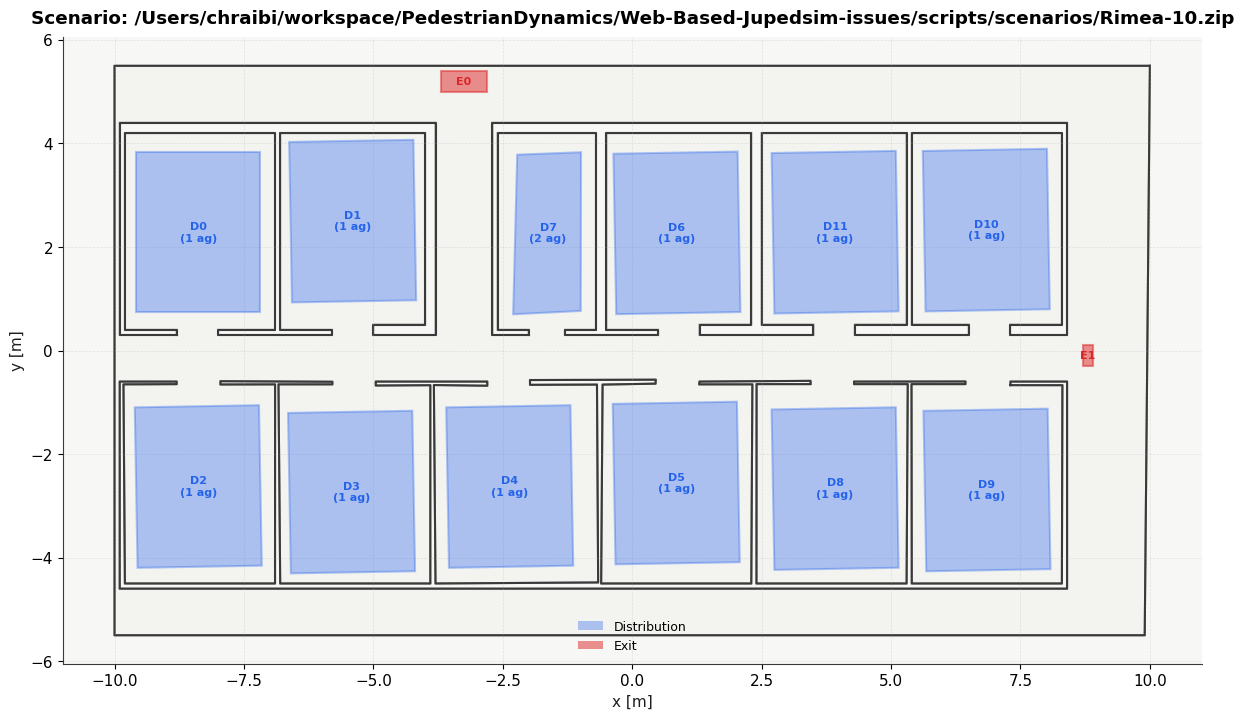

In [3]:
base.plot()
plt.show()

## 2. Index Aliases and Input Validation

Use integer indices instead of opaque string IDs like `"jps-distributions_7"`. Invalid inputs raise immediately instead of silently corrupting the scenario.

In [4]:
# Index alias: set_agent_count(0, ...) instead of set_agent_count("jps-distributions_0", ...)
base.set_agent_count(0, 5)
print(f"Distribution 0 now has {base.list_distributions()[0]['agents']} agents")

# String keys still work
base.set_agent_count("jps-distributions_0", 1)
print(f"Distribution 0 reset to {base.list_distributions()[0]['agents']} agent")

# Validation catches mistakes early
for label, fn in [
    ("Negative count",    lambda: base.set_agent_count(0, -1)),
    ("Negative seed",     lambda: base.set_seed(-5)),
    ("Zero max time",     lambda: base.set_max_time(0)),
    ("Radius too large",  lambda: base.set_agent_params(0, radius=2.0)),
    ("Speed too large",   lambda: base.set_agent_params(0, desired_speed=10.0)),
]:
    try:
        fn()
        print(f"  {label}: ERROR — should have raised!")
    except ValueError as e:
        print(f"  {label}: caught ValueError")

Distribution 0 now has 5 agents
Distribution 0 reset to 1 agent
  Negative count: caught ValueError
  Negative seed: caught ValueError
  Zero max time: caught ValueError
  Radius too large: caught ValueError
  Speed too large: caught ValueError


## 3. Safe Copies for Parameter Sweeps

`scenario.copy()` returns an independent deep copy. No more `from copy import deepcopy` boilerplate, and no risk of accidentally mutating the base scenario.

In [5]:
# Prove that copy() is independent
base.set_agent_count(0, 1)  # reset
s_copy = base.copy()
s_copy.set_agent_count(0, 99)

print(f"Original distribution 0: {base.list_distributions()[0]['agents']} agent")
print(f"Copy distribution 0:     {s_copy.list_distributions()[0]['agents']} agents")
assert base.list_distributions()[0]["agents"] == 1
assert s_copy.list_distributions()[0]["agents"] == 99

Original distribution 0: 1 agent
Copy distribution 0:     99 agents


## 4. Route-Choice Sweep: Crowd Size vs. Evacuation Time

RiMEA 10 has 12 rooms feeding into 2 exits. We scale agent counts uniformly across all distributions and measure evacuation time over multiple seeds.

The sweep loop is concise thanks to `copy()` and index aliases — no string-key bookkeeping.

In [6]:
%%capture
agents_per_room = [1, 3, 5, 8]
seeds = [42, 43, 44]
n_distributions = len(base.list_distributions())

results = {}
for n in agents_per_room:
    scenario = base.copy()
    scenario.set_max_time(500)
    for i in range(n_distributions):
        scenario.set_agent_count(i, n)

    evac_times = []
    for seed in seeds:
        result = run_scenario(scenario, seed=seed)
        evac_times.append(result.evacuation_time)
        result.cleanup()

    total = n * n_distributions
    results[total] = np.array(evac_times)
    print(f"{total:3d} agents -> {np.mean(evac_times):.1f}s (seeds: {evac_times})")

## 5. Results

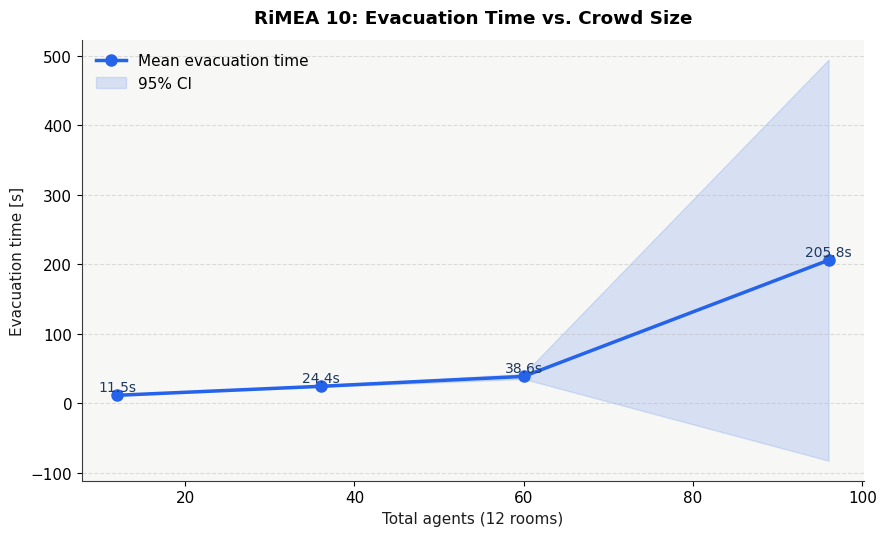

   12 agents -> mean 11.47s, std 0.53s
   36 agents -> mean 24.36s, std 0.98s
   60 agents -> mean 38.61s, std 3.23s
   96 agents -> mean 205.76s, std 254.82s


In [7]:
totals = sorted(results.keys())
means = np.array([results[t].mean() for t in totals])
stds = np.array([results[t].std(ddof=1) for t in totals])
cis = 1.96 * stds / np.sqrt(len(seeds))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(totals, means, marker="o", color="#2563EB", linewidth=2.5, markersize=8,
        label="Mean evacuation time")
ax.fill_between(totals, means - cis, means + cis, color="#2563EB", alpha=0.15,
                label="95% CI")
for x, y in zip(totals, means):
    ax.text(x, y + max(means) * 0.03, f"{y:.1f}s", ha="center", fontsize=10, color="#1e3a5f")

ax.set_xlabel("Total agents (12 rooms)")
ax.set_ylabel("Evacuation time [s]")
ax.set_title("RiMEA 10: Evacuation Time vs. Crowd Size", pad=12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

for t in totals:
    vals = results[t]
    print(f"  {t:3d} agents -> mean {vals.mean():.2f}s, std {vals.std(ddof=1):.2f}s")

## 6. Zone and Checkpoint Setters

Scenarios with zones or checkpoints can now be tweaked with dedicated setters instead of editing `raw` dicts.

Zones before:
  {'index': 0, 'id': 'jps-zones_0', 'speed_factor': 0.4}

Zones after set_zone_speed_factor(0, 0.5):
  {'index': 0, 'id': 'jps-zones_0', 'speed_factor': 0.5}


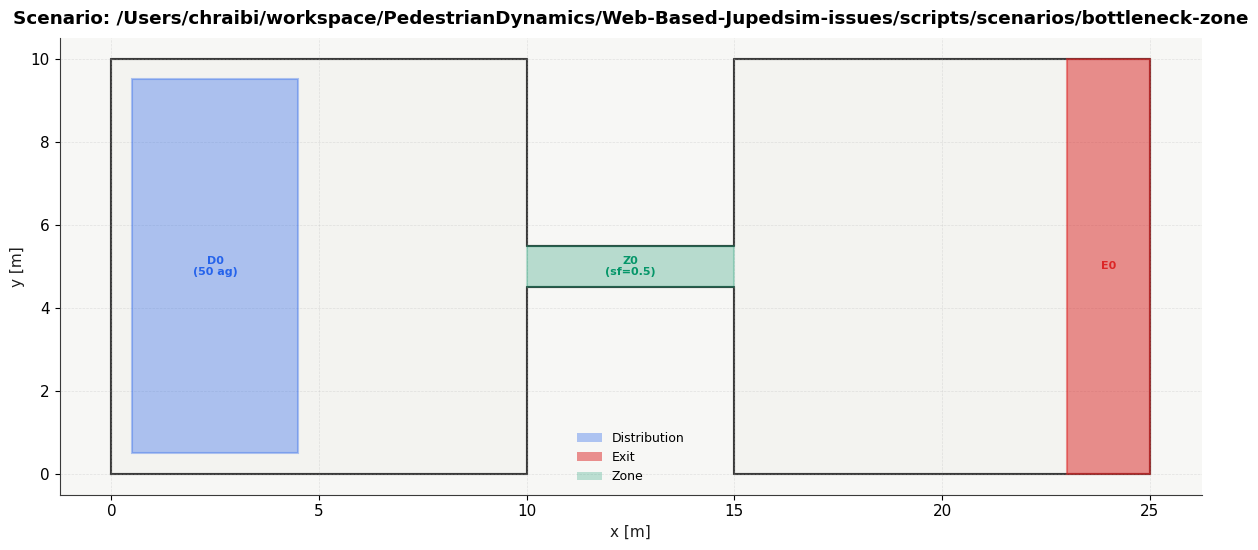


Checkpoints before:
  {'index': 0, 'id': 'jps-checkpoints_0', 'waiting_time': 5.0}

Checkpoints after set_checkpoint_waiting_time(0, 10.0):
  {'index': 0, 'id': 'jps-checkpoints_0', 'waiting_time': 10.0}


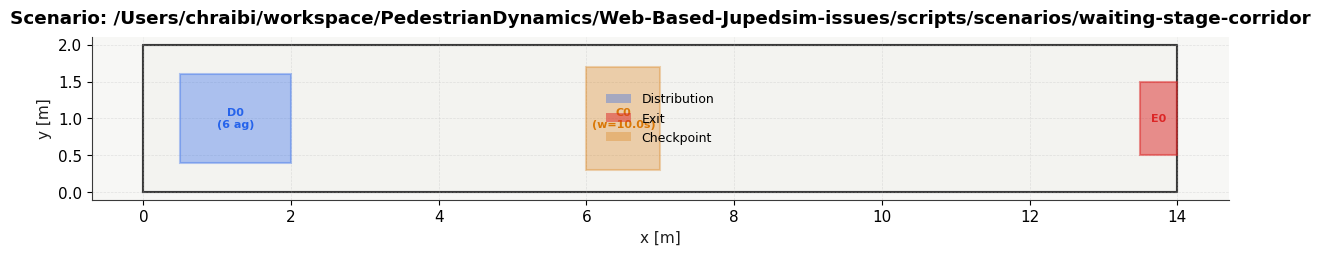

In [8]:
# --- Zones (bottleneck-zone scenario) ---
zone_scenario = load_scenario("scenarios/bottleneck-zone")
print("Zones before:")
for z in zone_scenario.list_zones():
    print(f"  {z}")

zone_scenario.set_zone_speed_factor(0, 0.5)
print("\nZones after set_zone_speed_factor(0, 0.5):")
for z in zone_scenario.list_zones():
    print(f"  {z}")

zone_scenario.plot()
plt.show()

# --- Checkpoints (waiting-stage-corridor scenario) ---
cp_scenario = load_scenario("scenarios/waiting-stage-corridor")
print("\nCheckpoints before:")
for s in cp_scenario.list_stages():
    print(f"  {s}")

cp_scenario.set_checkpoint_waiting_time(0, 10.0)
print("\nCheckpoints after set_checkpoint_waiting_time(0, 10.0):")
for s in cp_scenario.list_stages():
    print(f"  {s}")

cp_scenario.plot()
plt.show()

## Summary

The new API methods replace low-level dict manipulation with a clean, discoverable interface:

```python
# Before (error-prone, verbose)
from copy import deepcopy
s2 = deepcopy(scenario)
dist_key = list(s2.distributions.keys())[7]
s2.distributions[dist_key]["parameters"]["number"] = 50
s2.raw["zones"]["jps-zones_0"]["speed_factor"] = 0.5

# After (concise, validated)
s2 = scenario.copy()
s2.set_agent_count(7, 50)
s2.set_zone_speed_factor(0, 0.5)
```